#SLEEP DEBT & SCREEN TIME: LATE-NIGHT PHONE HABITS
###Final Data Analytics Python Project

**Prepared by:** Joana Belizaire


**Date:** September 2026

### Dataset Source and Recency

- **Source:** Kaggle
- **Dataset:** Sleep Debt & Screen Time: Late Night Phone Habits
- **Creator:** Samar Talwar
- **Retrieved:** September 2026
- **Dataset status at retrieval:** Recently published/updated on Kaggle
- **Recency:** The dataset was approximately 3 days old when it was selected for this project.

This recent dataset was selected to explore current patterns between bedtime phone use, sleep duration, sleep latency, and related sleep behaviors.

## Project Overview

This project analyzes the relationship between late-night screen time, sleep patterns, and next-day fatigue. The goal is to explore whether nighttime phone habits are associated with sleep duration, sleep quality, and how individuals feel the following day.

The analysis will include data cleaning, descriptive statistics, exploratory data analysis, and visualizations to identify meaningful patterns in the dataset.


***Central Research Questions***


How are late-night phone habits associated with sleep patterns and next-day fatique?

***Supporting Research Questions***
1. How does bedtime phone use vary by age?
2. Is there a difference in bedtime phone use between genders?
3. How does bedtime phone use vary by occupation type?
4. Which bedtime apps are associated with the highest phone use?
5. What is the relationship between bedtime phone use and total sleep duration?
6. What is the relationship between bedtime phone use and sleep latency?

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading the Dataset from Google Drive
df = pd.read_csv("/content/drive/MyDrive/Final Data Analytics Python Project/bedtime_screentime_sleep_debt.csv")

In [4]:
#Overview Dataset
df.head()

,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
0,USR-00001,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt
1,USR-00002,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt
2,USR-00003,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt
3,USR-00004,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7,Mild Deficit
4,USR-00005,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3,Moderate Debt


In [5]:
# Column names
df.columns

Index(['user_id', 'age', 'gender', 'occupation_type', 'chronotype',
       'bedtime_phone_minutes', 'primary_bedtime_app', 'screen_brightness_pct',
       'blue_light_filter_active', 'caffeine_post_5pm_mg',
       'physical_activity_min', 'sleep_latency_min', 'total_sleep_hours',
       'deep_sleep_pct', 'rem_sleep_pct', 'morning_alarm_snoozes',
       'next_day_fatigue_score', 'sleep_debt_category'],
      dtype='object')

## Data Cleaning and Preparation

Before conducting the analysis, the dataset was assessed for data quality.
The cleaning process includes checking data types, missing values,
duplicate records, inconsistent categories, invalid values, and columns
that may not be relevant to the analysis.

## Dataset Overview

The dataset contains 8,500 participant records and 18 original variables related to demographics, bedtime phone behavior, lifestyle factors, and sleep outcomes.

Key variables used in this analysis include age, gender, occupation type, bedtime phone minutes, primary bedtime app, total sleep hours, sleep latency, and next-day fatigue score.

In [6]:
# Dataset dimensions
print("Dataset shape:", df.shape)

Dataset shape: (8500, 18)


In [7]:
# Data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8500 non-null   object 
 1   age                       8500 non-null   int64  
 2   gender                    8500 non-null   object 
 3   occupation_type           8500 non-null   object 
 4   chronotype                8500 non-null   object 
 5   bedtime_phone_minutes     8500 non-null   int64  
 6   primary_bedtime_app       8500 non-null   object 
 7   screen_brightness_pct     8500 non-null   int64  
 8   blue_light_filter_active  8500 non-null   int64  
 9   caffeine_post_5pm_mg      8500 non-null   int64  
 10  physical_activity_min     8500 non-null   int64  
 11  sleep_latency_min         8500 non-null   float64
 12  total_sleep_hours         8500 non-null   float64
 13  deep_sleep_pct            8500 non-null   float64
 14  rem_slee

In [8]:
# Check missing values
df.isnull().sum()

,0
user_id,0
age,0
gender,0
occupation_type,0
chronotype,0
bedtime_phone_minutes,0
primary_bedtime_app,0
screen_brightness_pct,0
blue_light_filter_active,0
caffeine_post_5pm_mg,0


No missing values were identified in the dataset.

In [9]:
# Check duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


No duplicate records were identified.

In [10]:
df_clean = df.copy()

df_clean.drop(columns=['user_id'], inplace=True)

In [11]:
#Category Columns
categorical_columns = [
    'gender',
    'occupation_type',
    'chronotype',
    'primary_bedtime_app',
    'sleep_debt_category'
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())


gender:
gender
Female        4347
Male          3905
Non-Binary     248
Name: count, dtype: int64

occupation_type:
occupation_type
Corporate 9-to-5             2838
Remote Tech                  2142
Student                      1622
Healthcare / Shift Worker     997
Freelance / Creative          901
Name: count, dtype: int64

chronotype:
chronotype
Intermediate    3880
Night Owl       2455
Morning Lark    2165
Name: count, dtype: int64

primary_bedtime_app:
primary_bedtime_app
TikTok / Reels              2198
YouTube                     1928
Instagram / Reddit          1630
Streaming (Netflix/Hulu)    1301
Messaging / Chat             847
News / Reading               596
Name: count, dtype: int64

sleep_debt_category:
sleep_debt_category
Moderate Debt        4462
Mild Deficit         2004
Optimal Recovery     1387
Severe Sleep Debt     647
Name: count, dtype: int64


### Numerical Data Validation

Numerical variables were examined using descriptive statistics to identify
potential invalid values, unusual ranges, and possible outliers before
conducting the exploratory analysis.

In [12]:
# Summary statistics for numerical columns
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
age,8500.0,34.355647,11.584259,18.0,25.00,32.00,42.00,65.0
bedtime_phone_minutes,8500.0,59.250000,36.931991,1.0,31.00,51.00,79.00,180.0
screen_brightness_pct,8500.0,55.153882,19.850550,10.0,42.00,55.00,69.00,100.0
blue_light_filter_active,8500.0,0.467765,0.498989,0.0,0.00,0.00,1.00,1.0
caffeine_post_5pm_mg,8500.0,33.222471,51.935645,0.0,0.00,0.00,55.00,250.0
physical_activity_min,8500.0,35.701412,20.819390,0.0,21.00,35.00,50.00,112.0
sleep_latency_min,8500.0,40.671471,17.444914,6.0,28.20,37.60,49.70,123.3
total_sleep_hours,8500.0,6.266209,1.446258,3.2,5.24,6.33,7.35,9.8
deep_sleep_pct,8500.0,21.735741,3.069377,8.1,19.70,21.90,23.90,28.0
rem_sleep_pct,8500.0,19.105859,2.546459,9.6,17.40,19.10,20.80,27.0


### Data Validation

The numerical variables were reviewed to identify values outside their
expected ranges. Range checks were performed on key variables before
continuing with the analysis.

In [13]:
# Check values outside expected ranges

print("Age outside 18–65:",
      ((df_clean['age'] < 18) | (df_clean['age'] > 65)).sum())

print("Screen brightness outside 0–100:",
      ((df_clean['screen_brightness_pct'] < 0) |
       (df_clean['screen_brightness_pct'] > 100)).sum())

print("Total sleep outside 0–24 hours:",
      ((df_clean['total_sleep_hours'] < 0) |
       (df_clean['total_sleep_hours'] > 24)).sum())

print("Deep sleep percentage outside 0–100:",
      ((df_clean['deep_sleep_pct'] < 0) |
       (df_clean['deep_sleep_pct'] > 100)).sum())

print("REM sleep percentage outside 0–100:",
      ((df_clean['rem_sleep_pct'] < 0) |
       (df_clean['rem_sleep_pct'] > 100)).sum())

print("Fatigue score outside 1–10:",
      ((df_clean['next_day_fatigue_score'] < 1) |
       (df_clean['next_day_fatigue_score'] > 10)).sum())

Age outside 18–65: 0
Screen brightness outside 0–100: 0
Total sleep outside 0–24 hours: 0
Deep sleep percentage outside 0–100: 0
REM sleep percentage outside 0–100: 0
Fatigue score outside 1–10: 0


**Validation Result:** No values were identified outside the expected ranges for the variables tested. Therefore, no records were removed based on these validation checks.

## Feature Engineering

To support demographic analysis, participants were grouped into age categories.
This allows bedtime phone usage, sleep patterns, and next-day fatigue to be
compared across different age groups.

In [14]:
# Create age groups

age_bins = [17, 24, 34, 44, 54, 65]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-65']

df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=age_bins,
    labels=age_labels)

In [15]:
#Verifying the new dataset
df_clean.head()

,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category,age_group
0,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt,25-34
1,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt,55-65
2,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt,35-44
3,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7,Mild Deficit,35-44
4,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3,Moderate Debt,18-24


In [16]:
# Check Age Group Distribution
df_clean['age_group'].value_counts().sort_index()

,count
age_group,
18-24,1915
25-34,2940
35-44,1948
45-54,1043
55-65,654


In [17]:
## Check Gender Distribution
gender_counts = df_clean['gender'].value_counts()
print(gender_counts)

gender
Female        4347
Male          3905
Non-Binary     248
Name: count, dtype: int64


In [18]:
## Check OccupationDistribution
occupation_counts = df_clean['occupation_type'].value_counts()
print(occupation_counts)

occupation_type
Corporate 9-to-5             2838
Remote Tech                  2142
Student                      1622
Healthcare / Shift Worker     997
Freelance / Creative          901
Name: count, dtype: int64


# Exploratory Data Analysis (EDA)

This section explores patterns and relationships in the dataset to answer the research questions. The analysis focuses on demographic characteristics, bedtime phone habits, sleep patterns, sleep debt, and next-day fatigue.

## 1. Demographic Analysis

Before examining sleep and phone-use patterns, the demographic characteristics of the participants are explored by age, gender, and occupation type.

### 1.1 Age Distribution

**Question:** What is the age distribution of participants in the dataset?

This analysis examines how the 8,500 participants are distributed across different age groups.

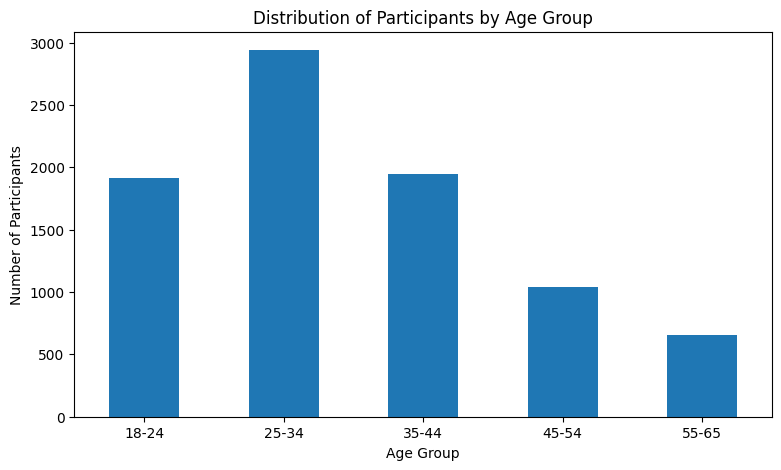

In [19]:
import matplotlib.pyplot as plt

# Count participants in each age group
age_counts = df_clean['age_group'].value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(9, 5))
age_counts.plot(kind='bar')

plt.title('Distribution of Participants by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Participants')
plt.xticks(rotation=0)

plt.show()

*Finding:* The 25–34 age group has the largest number of participants (2,940), followed by the 35–44 group (1,948) and the 18–24 group (1,915). The 55–65 age group has the fewest participants (654).

### 1.2 Gender Distribution

*Question:* How are participants distributed by gender?

This analysis examines the gender composition of the dataset.

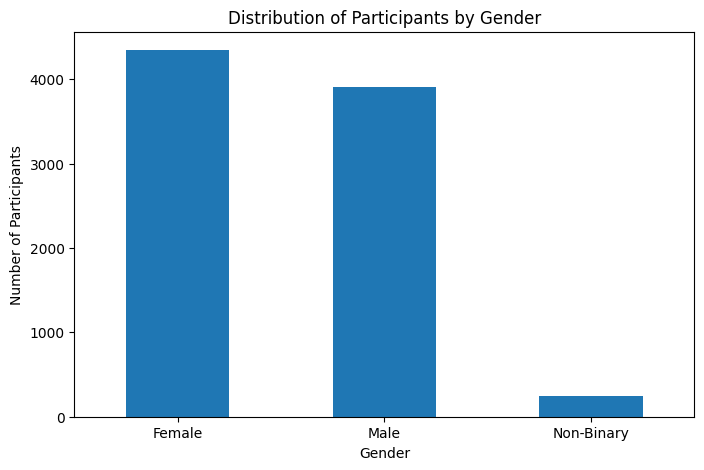

In [20]:
gender_counts = df_clean['gender'].value_counts()

plt.figure(figsize=(8, 5))
gender_counts.plot(kind='bar')

plt.title('Distribution of Participants by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Participants')
plt.xticks(rotation=0)

plt.show()

*Finding:* Female participants represent the largest group in the dataset with 4,347 participants, followed by males with 3,905 participants. Non-binary participants represent the smallest group with 248 participants.

### 1.3 Occupation Distribution

*Question:* What are the most common occupation types among participants?

This analysis examines the occupational composition of the study population.

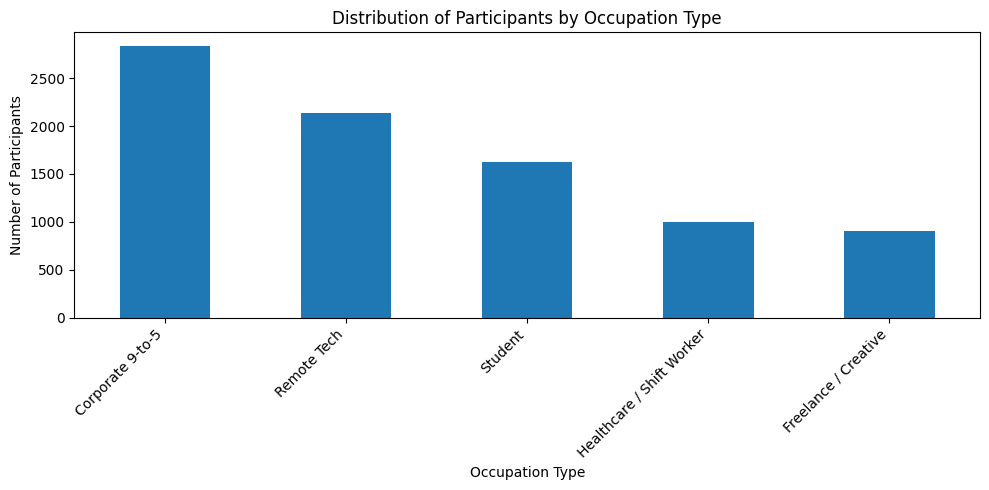

In [21]:
occupation_counts = df_clean['occupation_type'].value_counts()

plt.figure(figsize=(10, 5))
occupation_counts.plot(kind='bar')

plt.title('Distribution of Participants by Occupation Type')
plt.xlabel('Occupation Type')
plt.ylabel('Number of Participants')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

*Finding:* Corporate 9-to-5 workers are the largest occupational group in the dataset, followed by remote tech workers and students. Freelance/creative participants represent the smallest occupational group.

#Visualization Research Questions

## Bedtime Phone Usage Analysis

### Research Question 1: How does bedtime phone use vary across age groups?

This analysis compares the average number of minutes participants spend on their phones at bedtime across different age groups.

In [22]:
# Average bedtime phone use by age group
age_phone = (df_clean.groupby('age_group', observed=True)['bedtime_phone_minutes'].mean().round(2))
age_phone

,bedtime_phone_minutes
age_group,
18-24,60.41
25-34,59.03
35-44,59.56
45-54,57.11
55-65,59.36


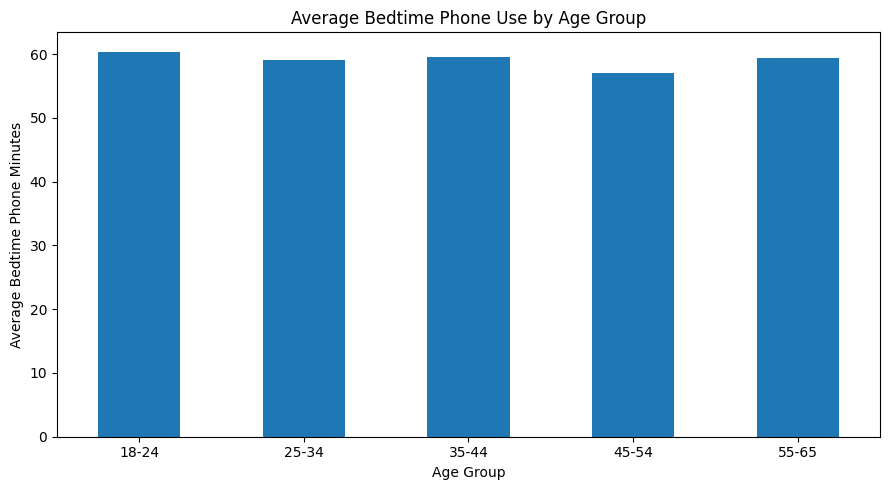

In [23]:
# Bar chart: Average bedtime phone use by age group

plt.figure(figsize=(9, 5))

age_phone.plot(kind='bar')

plt.title('Average Bedtime Phone Use by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Bedtime Phone Minutes')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

*Finding:* Bedtime phone use is relatively similar across all age groups. Participants aged 18–24 have the highest average bedtime phone use at 60.41 minutes, while participants aged 45–54 have the lowest average at 57.11 minutes. The small differences suggest that bedtime phone use does not vary substantially by age group in this dataset.

### Research Question 2: How does bedtime phone use vary by gender?

This analysis compares the average amount of time participants spend on their phones at bedtime across gender groups.

In [24]:
# Average bedtime phone use by gender

gender_phone = (df_clean.groupby('gender')['bedtime_phone_minutes'].mean().round(2))
gender_phone

,bedtime_phone_minutes
gender,
Female,59.24
Male,59.21
Non-Binary,59.96


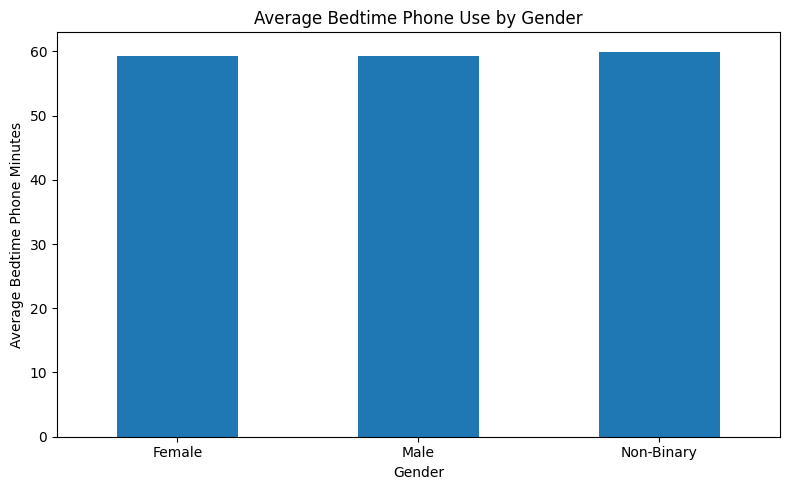

In [25]:
# Bar chart: Average bedtime phone use by gender

plt.figure(figsize=(8, 5))

gender_phone.plot(kind='bar')

plt.title('Average Bedtime Phone Use by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Bedtime Phone Minutes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding:** Average bedtime phone use was nearly identical across gender groups. Non-Binary participants had the highest average at 59.96 minutes, followed by Female participants at 59.24 minutes and Male participants at 59.21 minutes. The differences between the groups were very small.

### Research Question 3: How does bedtime phone use vary across occupation types?

This analysis compares the average amount of time participants spend on their phones at bedtime across different occupation types.

In [26]:
# Average bedtime phone use by occupation type

occupation_phone = (
    df_clean.groupby('occupation_type')['bedtime_phone_minutes']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

occupation_phone

,bedtime_phone_minutes
occupation_type,
Freelance / Creative,60.04
Remote Tech,59.40
Healthcare / Shift Worker,59.30
Corporate 9-to-5,59.07
Student,58.89


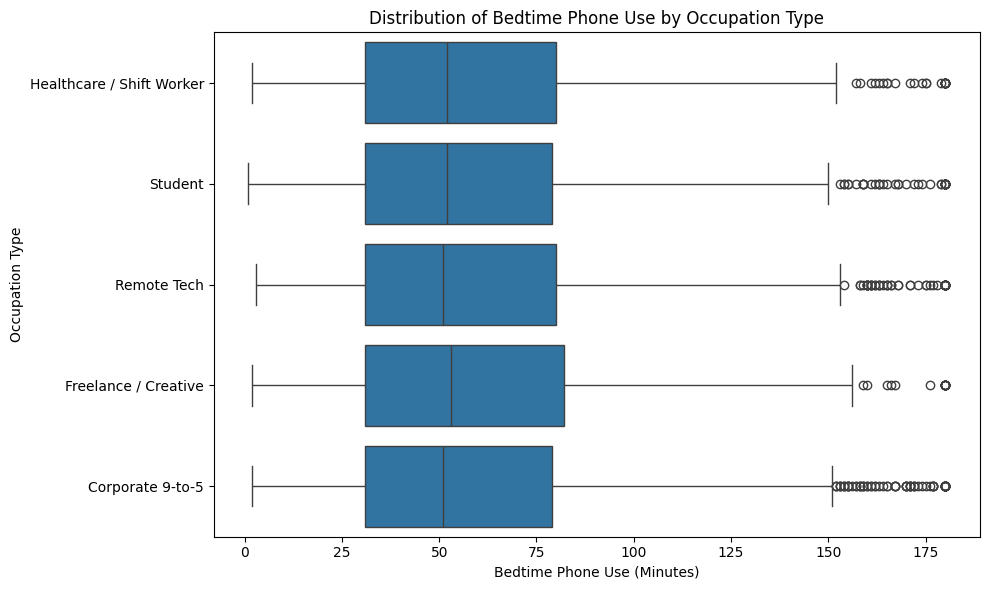

In [27]:
# Distribution of bedtime phone use by occupation type

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    y='occupation_type',
    x='bedtime_phone_minutes'
)

plt.title('Distribution of Bedtime Phone Use by Occupation Type')
plt.xlabel('Bedtime Phone Use (Minutes)')
plt.ylabel('Occupation Type')

plt.tight_layout()
plt.show()

**Finding:** Average bedtime phone use was similar across occupation types. Freelance/Creative participants had the highest average at 60.04 minutes, while Students had the lowest at 58.89 minutes. The difference between the highest and lowest groups was only 1.15 minutes.

### Research Question 4: Which bedtime apps are associated with the highest phone use?

This analysis examines whether average bedtime phone usage differs according to participants' primary bedtime app.

In [28]:
# Average bedtime phone use by primary bedtime app

app_phone = (
    df_clean.groupby('primary_bedtime_app')['bedtime_phone_minutes']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

app_phone

,bedtime_phone_minutes
primary_bedtime_app,
Instagram / Reddit,60.86
News / Reading,60.09
TikTok / Reels,59.85
Messaging / Chat,59.46
YouTube,58.29
Streaming (Netflix/Hulu),57.11


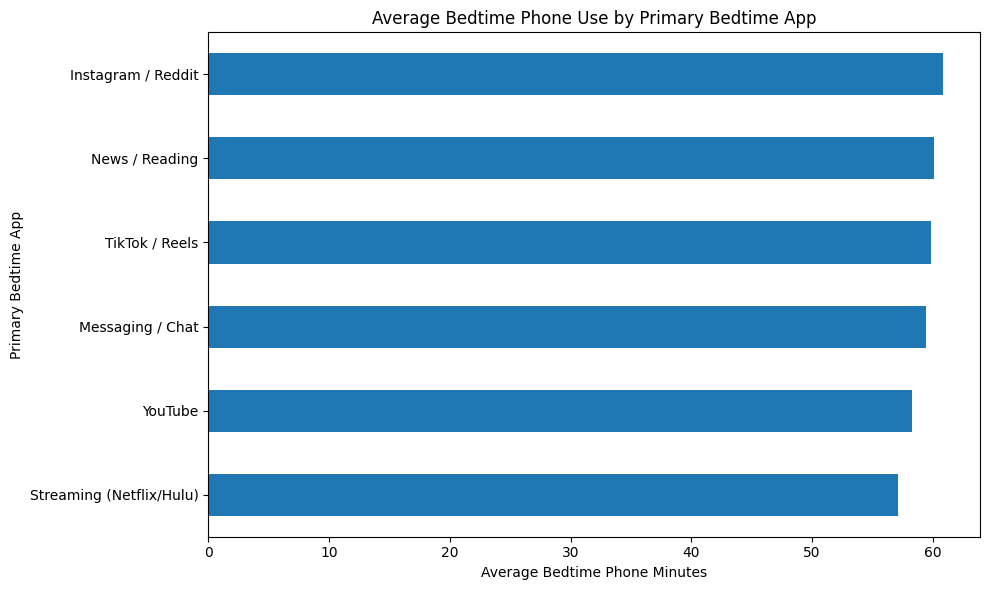

In [29]:
# Horizontal bar chart of average bedtime phone use by app

plt.figure(figsize=(10, 6))

app_phone.sort_values().plot(kind='barh')

plt.title('Average Bedtime Phone Use by Primary Bedtime App')
plt.xlabel('Average Bedtime Phone Minutes')
plt.ylabel('Primary Bedtime App')

plt.tight_layout()
plt.show()

**Finding:** Instagram / Reddit had the highest average at 60.86 minutes, followed by News / Reading at 60.09 minutes. Streaming (Netflix/Hulu) had the lowest average at 57.11 minutes, a difference of 3.75 minutes.

### Research Question 5: What is the relationship between bedtime phone use and total sleep duration?

This analysis examines whether the amount of time participants spend on their phones at bedtime is associated with the total number of hours they sleep.

In [30]:
# Correlation between bedtime phone use and total sleep hours

phone_sleep_corr = df_clean['bedtime_phone_minutes'].corr(
    df_clean['total_sleep_hours']
)

print("Correlation:", round(phone_sleep_corr, 3))

Correlation: -0.554


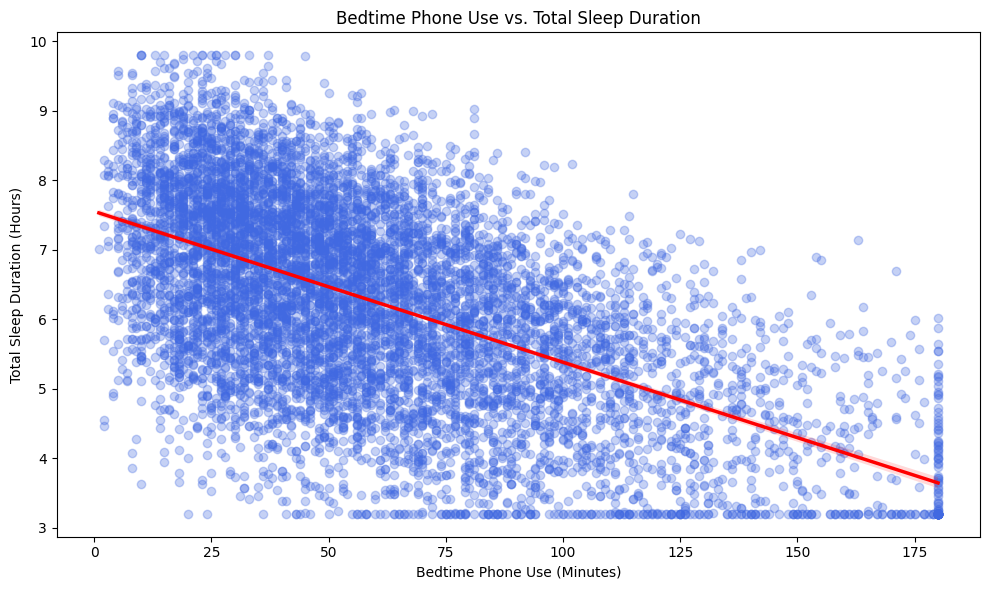

In [31]:
# Relationship between bedtime phone use and total sleep duration

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean,
    x='bedtime_phone_minutes',
    y='total_sleep_hours',
    scatter_kws={
        'alpha': 0.30,
        'color': 'royalblue'
    },
    line_kws={
        'linewidth': 2.5,
        'color': 'red'
    }
)

plt.title('Bedtime Phone Use vs. Total Sleep Duration')
plt.xlabel('Bedtime Phone Use (Minutes)')
plt.ylabel('Total Sleep Duration (Hours)')

plt.tight_layout()
plt.show()

Finding: There is a moderate negative correlation (r = -0.554) between bedtime phone use and total sleep duration. Participants who spent more time on their phones at bedtime tended to report fewer total hours of sleep. This indicates an association between higher bedtime phone use and shorter sleep duration; however, the correlation does not establish causation.

### Research Question 6: What is the relationship between bedtime phone use and sleep latency?

This analysis examines whether spending more time on the phone at bedtime is associated with taking longer to fall asleep.

In [32]:
# Correlation between bedtime phone use and sleep latency

phone_latency_corr = df_clean['bedtime_phone_minutes'].corr(
    df_clean['sleep_latency_min']
)

print("Correlation:", round(phone_latency_corr, 3))

Correlation: 0.858


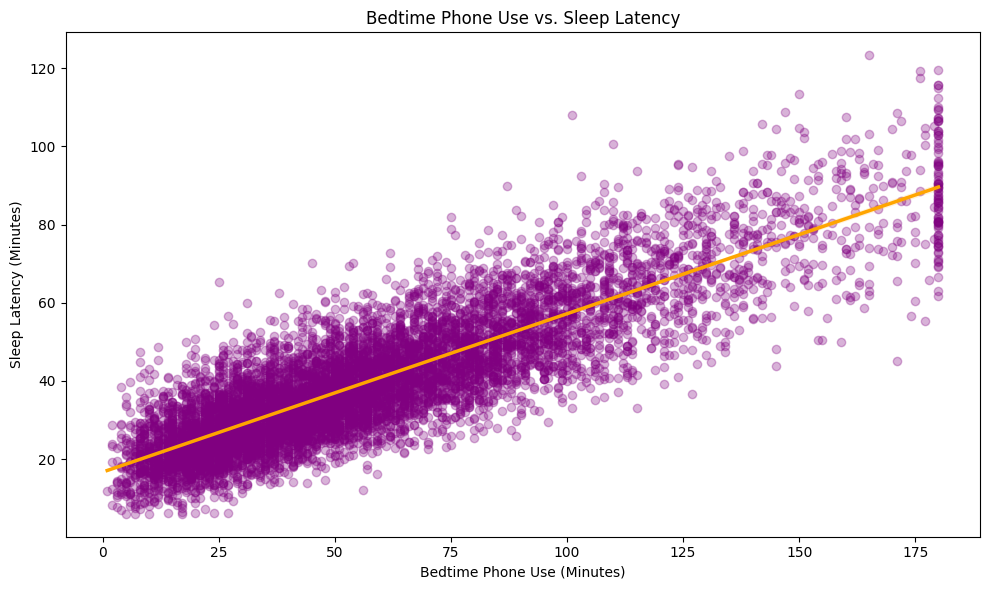

In [33]:
# Relationship between bedtime phone use and sleep latency

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clean,
    x='bedtime_phone_minutes',
    y='sleep_latency_min',
    scatter_kws={
        'alpha': 0.30,
        'color': 'purple'
    },
    line_kws={
        'linewidth': 2.5,
        'color': 'orange'
    }
)

plt.title('Bedtime Phone Use vs. Sleep Latency')
plt.xlabel('Bedtime Phone Use (Minutes)')
plt.ylabel('Sleep Latency (Minutes)')

plt.tight_layout()
plt.show()

*Finding:* There is a strong positive correlation (r = 0.858) between bedtime phone use and sleep latency. Participants who spent more time on their phones at bedtime tended to take longer to fall asleep. This indicates a strong association between higher bedtime phone use and longer sleep latency; however, correlation does not establish causation.

## Overall Key Findings

The analysis produced several important findings:

- Bedtime phone use was relatively similar across age groups. Participants aged 18–24 had the highest average bedtime phone use at 60.4 minutes, while the 45–54 age group had the lowest average at 57.1 minutes.

- Bedtime phone use was also very similar across gender groups. Female and male participants both averaged 59.2 minutes, while non-binary participants averaged 60.0 minutes.

- Differences across occupation types were small. Freelance / Creative participants had the highest average bedtime phone use at 60.0 minutes, while students had the lowest average at 58.9 minutes.

- Instagram / Reddit users had the highest average bedtime phone use at 60.9 minutes, while Streaming (Netflix/Hulu) users had the lowest average at 57.1 minutes.

- A moderate negative correlation (r = -0.554) was found between bedtime phone use and total sleep duration. Higher bedtime phone use was associated with fewer hours of sleep.

- A strong positive correlation (r = 0.858) was found between bedtime phone use and sleep latency. Higher bedtime phone use was associated with taking longer to fall asleep.

## Conclusion

This analysis explored the relationship between bedtime phone use and sleep patterns using a dataset of 8,500 participants.

The results showed that average bedtime phone use did not vary substantially across demographic groups such as age, gender, and occupation. Differences across primary bedtime app categories were also relatively small.

However, stronger patterns appeared when bedtime phone use was compared directly with sleep outcomes. Higher bedtime phone use was moderately associated with shorter total sleep duration (r = -0.554) and strongly associated with longer sleep latency (r = 0.858).

Overall, the findings suggest that the amount of time spent using a phone at bedtime may be more closely associated with sleep outcomes than with demographic characteristics. These results demonstrate associations within this dataset and should not be interpreted as evidence that bedtime phone use directly causes changes in sleep.

## Limitations

- This analysis identifies associations between variables but does not establish cause-and-effect relationships.
- Other factors not examined in this analysis may also influence sleep duration and sleep latency.
- The findings are based on the participants represented in this dataset and may not necessarily represent every population.
- Some variables, such as bedtime phone use and sleep measures, should be interpreted according to how they were collected and defined in the original dataset.

## Recommendations and Future Analysis

Based on the findings of this analysis, future research could examine additional factors that may influence sleep outcomes, such as caffeine consumption, physical activity, screen brightness, blue light filter use, and chronotype.

Future analysis could also investigate whether combinations of bedtime behaviors are more strongly associated with sleep duration, sleep latency, and next-day fatigue than phone use alone.

These additional analyses could provide a more complete understanding of the relationship between bedtime habits and sleep.